<a href="https://colab.research.google.com/github/HarishRock0/DSGP/blob/child-protection-component/script/Phase_4_Regional_Assessment_and_Allocation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 4: Districtwise Assessment & Resource Allocation

## Objective
Transform engineered features into actionable resource allocation recommendations for 2025 by:
1. Creating a composite need index for each district
2. Ranking districts by priority
3. Generating allocation recommendations (percentages and budget amounts)
4. Validating results through comparison and sensitivity analysis

## Methodology Overview
- **Feature Selection**: 6-8 key features covering severity, trends, infrastructure, population
- **Weighting**: Domain-informed (40% current, 30% trends, 20% infrastructure, 10% population)
- **Allocation Formula**: Equitable with 5% floor (ensures every district gets baseline support)
- **Budget**: Interactive - user can input actual budget, with 50M rupees as default example

## Inputs
- `district_features.csv` from Phase 2

## Outputs
- `district_need_scores.csv`: Need scores and rankings
- `allocation_recommendations_2025.csv`: Final allocations (% and amounts)
- Comparison with baseline methods
- Sensitivity analysis
- Visualizations

## 1. Setup and Load Data

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML
import warnings
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.precision', 2)

print("Libraries imported successfully")

Mounted at /content/drive
Libraries imported successfully


In [2]:
# Configuration
INPUT_FILE = '/content/drive/My Drive/output/district_features.csv'
OUTPUT_FOLDER = '/content/drive/My Drive/output/'

# Default example budget (50 million rupees)
# WHY 50M: Representative allocation for district-level child welfare programs
# This is illustrative - users can input their actual budget below
DEFAULT_BUDGET = 50_000_000  # 50 million rupees

print(f"Configuration:")
print(f"  Input file: {INPUT_FILE}")
print(f"  Default example budget: {DEFAULT_BUDGET:,} rupees (50 Million)")
print(f"  Output folder: {OUTPUT_FOLDER}")

Configuration:
  Input file: /content/drive/My Drive/output/district_features.csv
  Default example budget: 50,000,000 rupees (50 Million)
  Output folder: /content/drive/My Drive/output/


In [3]:
# Load engineered features
features_df = pd.read_csv(INPUT_FILE)

print(f"Features loaded successfully")
print(f"Shape: {features_df.shape}")
print(f"Districts: {len(features_df)}")
print(f"\nDistricts in dataset: {sorted(features_df['District'].unique())}")
print(f"\nAvailable features: {len(features_df.columns) - 1}")

print("\nFirst few rows:")
print(features_df.head())

Features loaded successfully
Shape: (3, 42)
Districts: 3

Districts in dataset: ['Colombo', 'Hambantota', 'Matara']

Available features: 41

First few rows:
     District  total_child_population  total_population  abuse_cases  \
0     Colombo                  719417           2459983         1174   
1  Hambantota                  500804            680054          393   
2      Matara                  286323            869032          315   

   num_schools  num_students  num_teachers  num_childrens_homes  \
0          393        325525         17219                   22   
1          320        136902          7847                    4   
2          356        156180          9833                    5   

   children_in_homes  abuse_rate_per_1000  student_teacher_ratio  \
0                480                 1.63                  18.90   
1                 89                 0.78                  17.45   
2                 96                 1.10                  15.88   

   schools_p

## 2. Feature Selection for Composite Index

Select 6-8 key features that best capture resource allocation needs.

WHY THESE FEATURES:
- **Current Severity**: Addresses immediate needs
- **Trends**: Enables proactive allocation (prevention vs crisis response)
- **Infrastructure**: Identifies capacity gaps requiring investment
- **Population Dynamics**: Plans for future pressure

Each category aligns with different intervention strategies.

In [4]:
# Define feature categories and selections
# WHY: Organized by intervention type for clear policy connection

FEATURE_GROUPS = {
    'current_severity': {
        'features': ['abuse_rate_per_1000', 'abuse_cases'],
        'weight': 0.40,
        'rationale': 'Immediate need - districts with high current abuse require urgent intervention'
    },
    'trends': {
        'features': ['abuse_trend_slope', 'abuse_pct_change_3yr', 'abuse_acceleration'],
        'weight': 0.30,
        'rationale': 'Trajectory - worsening districts need preventive resources before crisis'
    },
    'infrastructure': {
        'features': ['student_teacher_ratio', 'schools_per_1000_children', 'children_per_home'],
        'weight': 0.20,
        'rationale': 'Capacity - poor infrastructure correlates with supervision gaps'
    },
    'population': {
        'features': ['child_pop_trend_slope'],
        'weight': 0.10,
        'rationale': 'Future pressure - growing populations need scaled resources'
    }
}

# Select best feature from each group based on availability
# WHY: Ensures coverage of all dimensions without redundancy

selected_features = {}

print("="*80)
print("FEATURE SELECTION FOR COMPOSITE NEED INDEX")
print("="*80)

for group_name, group_info in FEATURE_GROUPS.items():
    print(f"\n{group_name.upper().replace('_', ' ')} (Weight: {group_info['weight']*100:.0f}%)")
    print(f"Rationale: {group_info['rationale']}")
    print("Available features:")

    available = [f for f in group_info['features'] if f in features_df.columns]

    if len(available) > 0:
        # Select first available feature from group
        # WHY: Primary feature in each list is most direct indicator
        selected = available[0]
        selected_features[selected] = {
            'group': group_name,
            'group_weight': group_info['weight']
        }
        print(f"  SELECTED: {selected}")

        # Show other available features in group
        if len(available) > 1:
            print(f"  Also available: {', '.join(available[1:])}")
    else:
        print(f"  WARNING: No features available from this group")

print(f"\n{'='*80}")
print(f"TOTAL FEATURES SELECTED: {len(selected_features)}")
print(f"{'='*80}")

# Distribute group weight among selected features
# WHY: If multiple features from one group, split weight proportionally
group_counts = {}
for feature, info in selected_features.items():
    group = info['group']
    group_counts[group] = group_counts.get(group, 0) + 1

for feature, info in selected_features.items():
    group = info['group']
    info['weight'] = info['group_weight'] / group_counts[group]

print("\nFinal feature weights:")
for feature, info in selected_features.items():
    print(f"  {feature}: {info['weight']*100:.1f}%")

# Verify weights sum to 1.0
total_weight = sum(info['weight'] for info in selected_features.values())
print(f"\nTotal weight: {total_weight*100:.1f}% (should be 100%)")

if abs(total_weight - 1.0) > 0.01:
    print("WARNING: Weights do not sum to 100%. Normalizing...")
    for feature in selected_features:
        selected_features[feature]['weight'] /= total_weight

FEATURE SELECTION FOR COMPOSITE NEED INDEX

CURRENT SEVERITY (Weight: 40%)
Rationale: Immediate need - districts with high current abuse require urgent intervention
Available features:
  SELECTED: abuse_rate_per_1000
  Also available: abuse_cases

TRENDS (Weight: 30%)
Rationale: Trajectory - worsening districts need preventive resources before crisis
Available features:
  SELECTED: abuse_trend_slope
  Also available: abuse_pct_change_3yr, abuse_acceleration

INFRASTRUCTURE (Weight: 20%)
Rationale: Capacity - poor infrastructure correlates with supervision gaps
Available features:
  SELECTED: student_teacher_ratio
  Also available: schools_per_1000_children, children_per_home

POPULATION (Weight: 10%)
Rationale: Future pressure - growing populations need scaled resources
Available features:
  SELECTED: child_pop_trend_slope

TOTAL FEATURES SELECTED: 4

Final feature weights:
  abuse_rate_per_1000: 40.0%
  abuse_trend_slope: 30.0%
  student_teacher_ratio: 20.0%
  child_pop_trend_slope: 1

## 3. Feature Normalization

Transform selected features to 0-100 scale for comparability.

WHY MIN-MAX NORMALIZATION:
- Features have different scales (abuse rate: 2-5, student ratio: 14-20)
- Min-max scales all to 0-100 where 100 = worst, 0 = best
- Preserves relative distances between districts
- Intuitive interpretation (percentile-like)

In [5]:
def normalize_feature(series, higher_is_worse=True):
    """
    Normalize feature to 0-100 scale using min-max normalization.

    WHY THIS METHOD:
    - Min-max preserves relative distances
    - 0-100 scale is intuitive (like percentage)
    - Allows direct comparison across features

    Args:
        series: Pandas Series to normalize
        higher_is_worse: If True, higher values get higher scores (worse)
                        If False, lower values get higher scores (better)

    Returns:
        Normalized series (0-100)
    """
    min_val = series.min()
    max_val = series.max()

    if max_val == min_val:
        # All values are the same - return 50 (neutral)
        return pd.Series([50] * len(series), index=series.index)

    # Normalize to 0-1
    normalized = (series - min_val) / (max_val - min_val)

    # Reverse if higher is better
    if not higher_is_worse:
        normalized = 1 - normalized

    # Scale to 0-100
    return normalized * 100


# Determine which features should be reversed
# WHY: For allocation priority, higher score = more need
#      But for some features, higher value = better (e.g., more schools)

HIGHER_IS_WORSE = {
    'abuse_rate_per_1000': True,        # More abuse = worse
    'abuse_cases': True,                # More cases = worse
    'abuse_trend_slope': True,          # Increasing = worse
    'abuse_pct_change_3yr': True,       # Increasing = worse
    'abuse_acceleration': True,         # Speeding up = worse
    'student_teacher_ratio': True,      # More students per teacher = worse
    'schools_per_1000_children': False, # More schools = better (reverse)
    'children_per_home': True,          # More crowded = worse
    'child_pop_trend_slope': True,      # Growing population = more pressure
}

# Normalize selected features
normalized_df = features_df[['District']].copy()

print("="*80)
print("FEATURE NORMALIZATION")
print("="*80)

for feature in selected_features.keys():
    higher_worse = HIGHER_IS_WORSE.get(feature, True)
    normalized_df[feature + '_normalized'] = normalize_feature(
        features_df[feature],
        higher_is_worse=higher_worse
    )

    direction = "Higher = Worse" if higher_worse else "Higher = Better (reversed)"
    print(f"\n{feature}:")
    print(f"  Direction: {direction}")
    print(f"  Original range: {features_df[feature].min():.2f} to {features_df[feature].max():.2f}")
    print(f"  Normalized range: {normalized_df[feature + '_normalized'].min():.2f} to {normalized_df[feature + '_normalized'].max():.2f}")

print(f"\n{'='*80}")
print("Normalization complete. All features now on 0-100 scale.")
print("100 = Greatest need, 0 = Least need")
print(f"{'='*80}")

print("\nNormalized features:")
print(normalized_df)

FEATURE NORMALIZATION

abuse_rate_per_1000:
  Direction: Higher = Worse
  Original range: 0.78 to 1.63
  Normalized range: 0.00 to 100.00

abuse_trend_slope:
  Direction: Higher = Worse
  Original range: -1.93 to 5.92
  Normalized range: 0.00 to 100.00

student_teacher_ratio:
  Direction: Higher = Worse
  Original range: 15.88 to 18.90
  Normalized range: 0.00 to 100.00

child_pop_trend_slope:
  Direction: Higher = Worse
  Original range: 1686.17 to 11937.32
  Normalized range: 0.00 to 100.00

Normalization complete. All features now on 0-100 scale.
100 = Greatest need, 0 = Least need

Normalized features:
     District  abuse_rate_per_1000_normalized  abuse_trend_slope_normalized  \
0     Colombo                          100.00                         92.72   
1  Hambantota                            0.00                        100.00   
2      Matara                           37.23                          0.00   

   student_teacher_ratio_normalized  child_pop_trend_slope_normalized

## 4. Composite Need Score Calculation

Combine normalized features using domain-informed weights to create single need score.

WEIGHTING RATIONALE:
- 40% Current Severity: Addresses immediate suffering, politically visible
- 30% Trends: Prevents future crises, cost-effective intervention
- 20% Infrastructure: Fixes root causes, long-term impact
- 10% Population: Plans for future, ensures sustainability

This weighting balances reactive (current) and proactive (trends/infrastructure) allocation.

In [6]:
# Calculate composite need score
# WHY: Weighted sum combines multiple dimensions into single priority metric

normalized_df['composite_need_score'] = 0

print("="*80)
print("COMPOSITE NEED SCORE CALCULATION")
print("="*80)

print("\nFormula: Weighted sum of normalized features\n")

for feature, info in selected_features.items():
    weight = info['weight']
    normalized_col = feature + '_normalized'

    # Add weighted contribution to composite score
    normalized_df['composite_need_score'] += normalized_df[normalized_col] * weight

    print(f"{feature}:")
    print(f"  Weight: {weight*100:.1f}%")
    print(f"  Category: {info['group'].replace('_', ' ').title()}")
    print()

# Create final scoring dataframe
scoring_df = features_df[['District']].copy()
scoring_df['need_score'] = normalized_df['composite_need_score'].round(2)

# Add rank
# WHY: Ranking shows relative priority clearly
scoring_df['rank'] = scoring_df['need_score'].rank(ascending=False, method='min').astype(int)

# Sort by rank
scoring_df = scoring_df.sort_values('rank').reset_index(drop=True)

print("="*80)
print("NEED SCORES AND RANKINGS")
print("="*80)
print("\nScore Interpretation:")
print("  80-100: Critical need - Urgent intervention required")
print("  60-79:  High need - Significant resources required")
print("  40-59:  Moderate need - Standard allocation")
print("  20-39:  Low need - Minimal allocation")
print("  0-19:   Very low need - Maintenance only")
print()

print(scoring_df.to_string(index=False))

print(f"\n{'='*80}")

COMPOSITE NEED SCORE CALCULATION

Formula: Weighted sum of normalized features

abuse_rate_per_1000:
  Weight: 40.0%
  Category: Current Severity

abuse_trend_slope:
  Weight: 30.0%
  Category: Trends

student_teacher_ratio:
  Weight: 20.0%
  Category: Infrastructure

child_pop_trend_slope:
  Weight: 10.0%
  Category: Population

NEED SCORES AND RANKINGS

Score Interpretation:
  80-100: Critical need - Urgent intervention required
  60-79:  High need - Significant resources required
  40-59:  Moderate need - Standard allocation
  20-39:  Low need - Minimal allocation
  0-19:   Very low need - Maintenance only

  District  need_score  rank
   Colombo       90.04     1
Hambantota       50.35     2
    Matara       14.89     3



## 5. Priority Tier Categorization

Group districts into priority tiers for differentiated intervention strategies.

In [7]:
# Assign priority tiers based on need scores
# WHY: Tiers enable differentiated intervention strategies

def assign_tier(score):
    """
    Assign priority tier based on need score.

    WHY THESE THRESHOLDS:
    - ≥75: Critical tier - Immediate crisis response needed
    - 50-74: High tier - Significant preventive intervention
    - <50: Moderate tier - Standard programs and monitoring

    With larger n, could use percentile-based tiers instead.
    """
    if score >= 75:
        return 'Tier 1 - Critical'
    elif score >= 50:
        return 'Tier 2 - High'
    else:
        return 'Tier 3 - Moderate'

scoring_df['tier'] = scoring_df['need_score'].apply(assign_tier)

print("="*80)
print("PRIORITY TIER ASSIGNMENT")
print("="*80)
print("\nDistricts by tier:\n")
print(scoring_df[['rank', 'District', 'need_score', 'tier']].to_string(index=False))

print("\n" + "="*80)
print("TIER PROFILES")
print("="*80)

for tier in scoring_df['tier'].unique():
    tier_districts = scoring_df[scoring_df['tier'] == tier]
    print(f"\n{tier}:")
    print(f"  Districts: {', '.join(tier_districts['District'].values)}")
    print(f"  Count: {len(tier_districts)}")
    print(f"  Avg Need Score: {tier_districts['need_score'].mean():.2f}")

    if 'Critical' in tier:
        print("  Recommended Action: Emergency response, infrastructure investment, enhanced monitoring")
    elif 'High' in tier:
        print("  Recommended Action: Preventive programs, capacity building, community engagement")
    else:
        print("  Recommended Action: Standard programs, routine monitoring, maintenance")

print("\n" + "="*80)

PRIORITY TIER ASSIGNMENT

Districts by tier:

 rank   District  need_score              tier
    1    Colombo       90.04 Tier 1 - Critical
    2 Hambantota       50.35     Tier 2 - High
    3     Matara       14.89 Tier 3 - Moderate

TIER PROFILES

Tier 1 - Critical:
  Districts: Colombo
  Count: 1
  Avg Need Score: 90.04
  Recommended Action: Emergency response, infrastructure investment, enhanced monitoring

Tier 2 - High:
  Districts: Hambantota
  Count: 1
  Avg Need Score: 50.35
  Recommended Action: Preventive programs, capacity building, community engagement

Tier 3 - Moderate:
  Districts: Matara
  Count: 1
  Avg Need Score: 14.89
  Recommended Action: Standard programs, routine monitoring, maintenance



## 6. Resource Allocation Formula

Convert need scores into allocation percentages using equitable approach.

ALLOCATION PHILOSOPHY:
- **Equitable with floor**: Every district gets minimum 5% (baseline services)
- **Proportional to need**: Remaining resources distributed by need score
- **Why not purely proportional**: All districts need basic child protection infrastructure

In [8]:
# Calculate allocation percentages
# WHY EQUITABLE WITH FLOOR:
# - Pure proportional could give <5% to some districts (insufficient for any program)
# - Floor ensures every district can operate minimum viable services
# - Remaining distributed by need (efficiency)

ALLOCATION_FLOOR = 5.0  # Minimum allocation percentage per district

num_districts = len(scoring_df)
total_floor = ALLOCATION_FLOOR * num_districts
remaining_allocation = 100 - total_floor

print("="*80)
print("ALLOCATION FORMULA")
print("="*80)
print(f"\nPhilosophy: Equitable with {ALLOCATION_FLOOR}% floor")
print(f"\nCalculation:")
print(f"  1. Every district gets {ALLOCATION_FLOOR}% baseline (total: {total_floor}%)")
print(f"  2. Remaining {remaining_allocation}% distributed proportionally by need score")
print(f"  3. Total = 100%")

# Step 1: Assign floor allocation
scoring_df['allocation_pct'] = ALLOCATION_FLOOR

# Step 2: Distribute remaining proportionally by need score
total_need_score = scoring_df['need_score'].sum()

for idx, row in scoring_df.iterrows():
    proportional_share = (row['need_score'] / total_need_score) * remaining_allocation
    scoring_df.at[idx, 'allocation_pct'] += proportional_share

# Round to 1 decimal place
scoring_df['allocation_pct'] = scoring_df['allocation_pct'].round(1)

# Adjust for rounding errors (ensure total = 100%)
total_allocation = scoring_df['allocation_pct'].sum()
if abs(total_allocation - 100.0) > 0.1:
    # Adjust highest allocation district
    adjustment = 100.0 - total_allocation
    highest_idx = scoring_df['allocation_pct'].idxmax()
    scoring_df.at[highest_idx, 'allocation_pct'] += adjustment
    scoring_df['allocation_pct'] = scoring_df['allocation_pct'].round(1)

print(f"\n{'='*80}")
print("ALLOCATION PERCENTAGES")
print("="*80)
print()
print(scoring_df[['rank', 'District', 'need_score', 'tier', 'allocation_pct']].to_string(index=False))
print(f"\nTotal: {scoring_df['allocation_pct'].sum():.1f}%")
print(f"\n{'='*80}")

ALLOCATION FORMULA

Philosophy: Equitable with 5.0% floor

Calculation:
  1. Every district gets 5.0% baseline (total: 15.0%)
  2. Remaining 85.0% distributed proportionally by need score
  3. Total = 100%

ALLOCATION PERCENTAGES

 rank   District  need_score              tier  allocation_pct
    1    Colombo       90.04 Tier 1 - Critical            54.2
    2 Hambantota       50.35     Tier 2 - High            32.6
    3     Matara       14.89 Tier 3 - Moderate            13.2

Total: 100.0%



## 7. Budget Allocation Calculator (Interactive)

Convert allocation percentages to actual budget amounts.

This section provides TWO options:
1. **Default Example**: 50 million rupees (illustrative)
2. **User Input**: Enter your actual budget to see customized allocations

The allocation percentages remain constant - only the budget amounts change.

In [9]:
def calculate_budget_allocation(scoring_df, total_budget):
    """
    Calculate budget amounts based on allocation percentages.

    WHY: Translates abstract percentages into concrete rupee amounts
         that organizations can actually work with.

    Args:
        scoring_df: DataFrame with allocation percentages
        total_budget: Total budget amount in rupees

    Returns:
        DataFrame with budget amounts added
    """
    result_df = scoring_df.copy()

    # Calculate budget amounts
    result_df['budget_amount'] = (result_df['allocation_pct'] / 100) * total_budget

    # Round to nearest thousand
    result_df['budget_amount'] = (result_df['budget_amount'] / 1000).round(0) * 1000

    # Adjust for rounding (ensure total equals input budget)
    total_allocated = result_df['budget_amount'].sum()
    if abs(total_allocated - total_budget) > 1000:
        adjustment = total_budget - total_allocated
        highest_idx = result_df['budget_amount'].idxmax()
        result_df.at[highest_idx, 'budget_amount'] += adjustment

    return result_df


def format_rupees(amount):
    """
    Format rupee amounts for display.

    WHY: Sri Lankan convention - uses lakhs and crores
         1 lakh = 100,000
         1 crore = 10,000,000
    """
    if amount >= 10_000_000:
        return f"{amount/10_000_000:.2f} Crore"
    elif amount >= 100_000:
        return f"{amount/100_000:.2f} Lakh"
    else:
        return f"{amount:,.0f}"


def display_allocation_table(result_df, total_budget, budget_label="Example Budget"):
    """
    Display formatted allocation table.
    """
    print("="*100)
    print(f"2025 RESOURCE ALLOCATION RECOMMENDATIONS")
    print(f"{budget_label}: {format_rupees(total_budget)} Rupees")
    print("="*100)
    print()

    # Create display dataframe
    display_df = pd.DataFrame({
        'Rank': result_df['rank'],
        'District': result_df['District'],
        'Need Score': result_df['need_score'],
        'Tier': result_df['tier'],
        'Allocation %': result_df['allocation_pct'].apply(lambda x: f"{x:.1f}%"),
        'Budget Amount': result_df['budget_amount'].apply(format_rupees)
    })

    print(display_df.to_string(index=False))
    print()
    print(f"Total Budget: {format_rupees(total_budget)} (100.0%)")
    print("="*100)


# Calculate with default example budget (50 million)
print("\n" + "#"*100)
print("#" + " "*98 + "#")
print("#" + " "*35 + "DEFAULT EXAMPLE ALLOCATION" + " "*37 + "#")
print("#" + " "*98 + "#")
print("#"*100 + "\n")

allocation_df = calculate_budget_allocation(scoring_df, DEFAULT_BUDGET)
display_allocation_table(allocation_df, DEFAULT_BUDGET, "Example Budget (Illustrative)")

print("\nNOTE: The above amounts are illustrative only, based on a hypothetical budget.")
print("      The allocation PERCENTAGES are the universal output of this model.")
print("      For your actual budget, use the calculator in the next cell.")


####################################################################################################
#                                                                                                  #
#                                   DEFAULT EXAMPLE ALLOCATION                                     #
#                                                                                                  #
####################################################################################################

2025 RESOURCE ALLOCATION RECOMMENDATIONS
Example Budget (Illustrative): 5.00 Crore Rupees

 Rank   District  Need Score              Tier Allocation % Budget Amount
    1    Colombo       90.04 Tier 1 - Critical        54.2%    2.71 Crore
    2 Hambantota       50.35     Tier 2 - High        32.6%    1.63 Crore
    3     Matara       14.89 Tier 3 - Moderate        13.2%    66.00 Lakh

Total Budget: 5.00 Crore (100.0%)

NOTE: The above amounts are illustrative only, based on a hypothetical

In [10]:
# INTERACTIVE BUDGET CALCULATOR
# Enter your actual budget below and run this cell

print("#"*100)
print("#" + " "*98 + "#")
print("#" + " "*30 + "INTERACTIVE BUDGET ALLOCATION CALCULATOR" + " "*27 + "#")
print("#" + " "*98 + "#")
print("#"*100)
print()
print("Enter your actual total budget for 2025 child welfare programs:")
print("(Press Enter to use default 50 million rupees)")
print()

# Get user input
try:
    user_input = input("Total Budget (in rupees): ")

    if user_input.strip() == "":
        user_budget = DEFAULT_BUDGET
        print(f"\nUsing default: {format_rupees(DEFAULT_BUDGET)} Rupees\n")
    else:
        # Remove commas if present
        user_input = user_input.replace(',', '').replace(' ', '')
        user_budget = float(user_input)

        if user_budget <= 0:
            print("\nERROR: Budget must be positive. Using default.\n")
            user_budget = DEFAULT_BUDGET
        else:
            print(f"\nCalculating allocation for: {format_rupees(user_budget)} Rupees\n")

    # Calculate allocation with user budget
    user_allocation_df = calculate_budget_allocation(scoring_df, user_budget)
    display_allocation_table(user_allocation_df, user_budget, "Your Budget")

    print("\nNOTE: The allocation percentages remain constant.")
    print("      Only the rupee amounts change based on your input budget.")
    print("\nTo recalculate with a different budget, simply rerun this cell.")

except ValueError:
    print("\nERROR: Invalid input. Please enter a numeric value.")
    print("Using default budget instead.\n")
    user_allocation_df = calculate_budget_allocation(scoring_df, DEFAULT_BUDGET)
    display_allocation_table(user_allocation_df, DEFAULT_BUDGET, "Default Budget")
except:
    print("\nNote: Interactive input not available in this environment.")
    print("Using default budget. To use custom budget, modify the code:\n")
    print("  YOUR_BUDGET = 75_000_000  # Enter your amount")
    print("  user_allocation_df = calculate_budget_allocation(scoring_df, YOUR_BUDGET)")
    print("  display_allocation_table(user_allocation_df, YOUR_BUDGET, 'Your Budget')\n")

    user_allocation_df = calculate_budget_allocation(scoring_df, DEFAULT_BUDGET)
    display_allocation_table(user_allocation_df, DEFAULT_BUDGET, "Default Budget")

####################################################################################################
#                                                                                                  #
#                              INTERACTIVE BUDGET ALLOCATION CALCULATOR                           #
#                                                                                                  #
####################################################################################################

Enter your actual total budget for 2025 child welfare programs:
(Press Enter to use default 50 million rupees)

Total Budget (in rupees): 1000000

Calculating allocation for: 10.00 Lakh Rupees

2025 RESOURCE ALLOCATION RECOMMENDATIONS
Your Budget: 10.00 Lakh Rupees

 Rank   District  Need Score              Tier Allocation % Budget Amount
    1    Colombo       90.04 Tier 1 - Critical        54.2%     5.42 Lakh
    2 Hambantota       50.35     Tier 2 - High        32.6%     3.26 Lakh
    3 

## 8. Alternative Budget Scenarios

Show how allocations change under different budget levels.

WHY: Organizations face budget uncertainty. Scenario planning helps with:
- Pessimistic case (budget cuts)
- Expected case (baseline)
- Optimistic case (increased funding)

In [11]:
# Generate scenario table
# WHY: Shows how allocations scale with budget (percentages stay constant)

SCENARIO_BUDGETS = {
    'Pessimistic (60%)': DEFAULT_BUDGET * 0.6,
    'Conservative (80%)': DEFAULT_BUDGET * 0.8,
    'Baseline (100%)': DEFAULT_BUDGET,
    'Optimistic (120%)': DEFAULT_BUDGET * 1.2,
    'Ambitious (150%)': DEFAULT_BUDGET * 1.5
}

print("="*120)
print("BUDGET SCENARIO ANALYSIS")
print("="*120)
print(f"\nShowing how allocations change under different budget levels.")
print(f"Note: Allocation PERCENTAGES remain constant; only rupee amounts change.\n")

# Create scenario table
scenario_data = []

for district in scoring_df['District']:
    district_pct = scoring_df[scoring_df['District'] == district]['allocation_pct'].values[0]

    row = {'District': district, 'Allocation %': f"{district_pct:.1f}%"}

    for scenario_name, budget in SCENARIO_BUDGETS.items():
        amount = (district_pct / 100) * budget
        row[scenario_name] = format_rupees(amount)

    scenario_data.append(row)

scenario_df = pd.DataFrame(scenario_data)

print(scenario_df.to_string(index=False))

print(f"\n{'='*120}")
print("\nInterpretation:")
print("  - Allocation percentages remain constant across all scenarios")
print("  - Rupee amounts scale proportionally with budget")
print("  - Even in pessimistic scenario, 5% floor ensures minimum viable services")
print(f"\n{'='*120}")

BUDGET SCENARIO ANALYSIS

Showing how allocations change under different budget levels.
Note: Allocation PERCENTAGES remain constant; only rupee amounts change.

  District Allocation % Pessimistic (60%) Conservative (80%) Baseline (100%) Optimistic (120%) Ambitious (150%)
   Colombo        54.2%        1.63 Crore         2.17 Crore      2.71 Crore        3.25 Crore       4.07 Crore
Hambantota        32.6%        97.80 Lakh         1.30 Crore      1.63 Crore        1.96 Crore       2.44 Crore
    Matara        13.2%        39.60 Lakh         52.80 Lakh      66.00 Lakh        79.20 Lakh       99.00 Lakh


Interpretation:
  - Allocation percentages remain constant across all scenarios
  - Rupee amounts scale proportionally with budget
  - Even in pessimistic scenario, 5% floor ensures minimum viable services



## 9. Comparison with Baseline Methods

Compare model allocations against naive baseline approaches.

WHY: Validates that model is better than simple heuristics.
If model matches equal allocation, it adds no value.

In [12]:
# Calculate baseline allocations
# WHY: Need to show model is superior to naive approaches

comparison_df = scoring_df[['District', 'need_score', 'allocation_pct']].copy()
comparison_df.columns = ['District', 'Need Score', 'Model Allocation %']

# Baseline 1: Equal allocation
# WHY: Simplest approach - every district gets same amount
comparison_df['Equal Allocation %'] = 100 / len(comparison_df)

# Baseline 2: Population-only allocation
# WHY: Common naive approach - more people = more resources
if 'total_child_population' in features_df.columns:
    total_child_pop = features_df['total_child_population'].sum()
    comparison_df['Population-Only %'] = (
        features_df.set_index('District')['total_child_population'] /
        total_child_pop * 100
    ).round(1).values

# Baseline 3: Abuse-only allocation
# WHY: Single-metric approach - allocate by current abuse cases only
if 'abuse_cases' in features_df.columns:
    total_abuse = features_df['abuse_cases'].sum()
    if total_abuse > 0:
        comparison_df['Abuse-Only %'] = (
            features_df.set_index('District')['abuse_cases'] /
            total_abuse * 100
        ).round(1).values

print("="*120)
print("COMPARISON WITH BASELINE ALLOCATION METHODS")
print("="*120)
print("\nComparing our model to three naive baselines:\n")
print("1. Equal: Every district gets equal share (33.3% each for 3 districts)")
print("2. Population-Only: Allocation proportional to child population")
print("3. Abuse-Only: Allocation proportional to current abuse cases")
print("4. Model: Our multi-factor weighted approach\n")

print(comparison_df.to_string(index=False))

print(f"\n{'='*120}")
print("KEY DIFFERENCES:")
print("="*120)

# Analyze differences
for idx, row in comparison_df.iterrows():
    district = row['District']
    model_alloc = row['Model Allocation %']
    equal_alloc = row['Equal Allocation %']

    diff_from_equal = model_alloc - equal_alloc

    print(f"\n{district}:")
    print(f"  Model allocation: {model_alloc:.1f}%")
    print(f"  Equal allocation: {equal_alloc:.1f}%")
    print(f"  Difference: {diff_from_equal:+.1f}% ", end="")

    if diff_from_equal > 5:
        print("(Model allocates MORE - higher need)")
        print(f"  Reason: Need score of {row['Need Score']:.1f} indicates critical/high priority")
    elif diff_from_equal < -5:
        print("(Model allocates LESS - lower need)")
        print(f"  Reason: Need score of {row['Need Score']:.1f} indicates moderate priority")
    else:
        print("(Similar to equal distribution)")

print(f"\n{'='*120}")
print("\nCONCLUSION:")
print("  Our model differentiates based on need, not just population or current abuse.")
print("  It considers trends, infrastructure, and future pressure - not captured by baselines.")
print(f"{'='*120}")

COMPARISON WITH BASELINE ALLOCATION METHODS

Comparing our model to three naive baselines:

1. Equal: Every district gets equal share (33.3% each for 3 districts)
2. Population-Only: Allocation proportional to child population
3. Abuse-Only: Allocation proportional to current abuse cases
4. Model: Our multi-factor weighted approach

  District  Need Score  Model Allocation %  Equal Allocation %  Population-Only %  Abuse-Only %
   Colombo       90.04                54.2               33.33               47.8          62.4
Hambantota       50.35                32.6               33.33               33.2          20.9
    Matara       14.89                13.2               33.33               19.0          16.7

KEY DIFFERENCES:

Colombo:
  Model allocation: 54.2%
  Equal allocation: 33.3%
  Difference: +20.9% (Model allocates MORE - higher need)
  Reason: Need score of 90.0 indicates critical/high priority

Hambantota:
  Model allocation: 32.6%
  Equal allocation: 33.3%
  Difference: -0

## 10. Visualizations

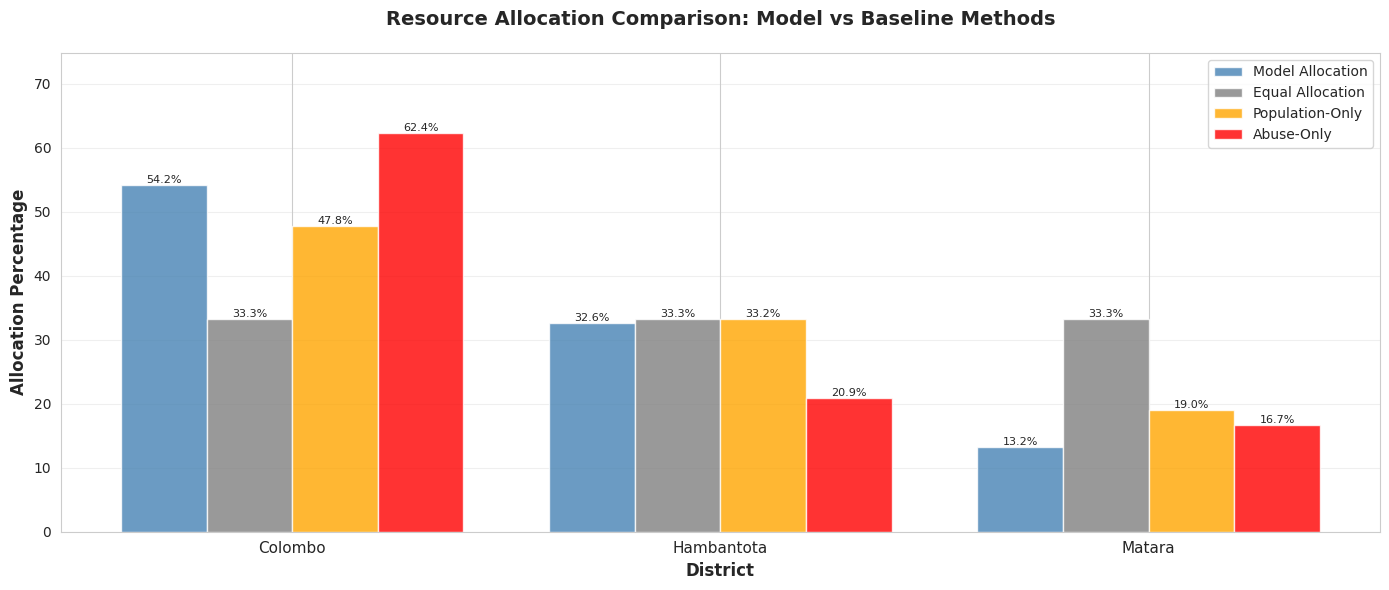

Allocation comparison chart saved to: allocation_comparison.png


In [13]:
# Visualization 1: Allocation Comparison Bar Chart
# WHY: Visual comparison makes differences immediately apparent

fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(comparison_df))
width = 0.2

methods = ['Model Allocation %', 'Equal Allocation %']
if 'Population-Only %' in comparison_df.columns:
    methods.append('Population-Only %')
if 'Abuse-Only %' in comparison_df.columns:
    methods.append('Abuse-Only %')

colors = ['steelblue', 'gray', 'orange', 'red']

for i, method in enumerate(methods):
    offset = (i - len(methods)/2) * width + width/2
    bars = ax.bar(x + offset, comparison_df[method], width,
                   label=method.replace(' %', ''),
                   color=colors[i], alpha=0.8)

    # Add value labels
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%',
                ha='center', va='bottom', fontsize=8)

ax.set_xlabel('District', fontsize=12, fontweight='bold')
ax.set_ylabel('Allocation Percentage', fontsize=12, fontweight='bold')
ax.set_title('Resource Allocation Comparison: Model vs Baseline Methods',
             fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['District'], fontsize=11)
ax.legend(fontsize=10, loc='upper right')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, max(comparison_df[methods].max().max() * 1.2, 50))

plt.tight_layout()
plt.savefig(OUTPUT_FOLDER + 'allocation_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("Allocation comparison chart saved to: allocation_comparison.png")

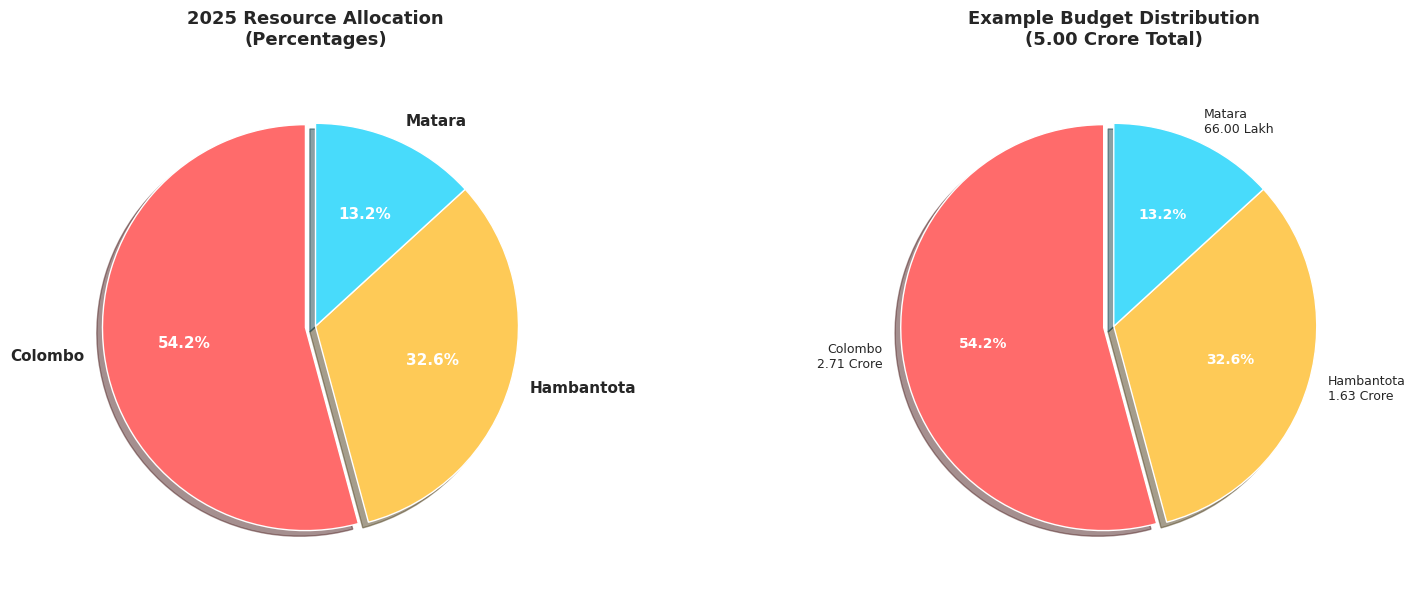

Allocation breakdown charts saved to: allocation_breakdown.png


In [14]:
# Visualization 2: Allocation Breakdown Pie Chart
# WHY: Pie chart shows proportion intuitively

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1: Allocation percentages
colors_pie = ['#ff6b6b', '#feca57', '#48dbfb']
explode = [0.05 if i == 0 else 0 for i in range(len(scoring_df))]

wedges, texts, autotexts = ax1.pie(
    scoring_df['allocation_pct'],
    labels=scoring_df['District'],
    autopct='%1.1f%%',
    startangle=90,
    colors=colors_pie[:len(scoring_df)],
    explode=explode,
    shadow=True
)

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(11)
    autotext.set_fontweight('bold')

for text in texts:
    text.set_fontsize(11)
    text.set_fontweight('bold')

ax1.set_title('2025 Resource Allocation\n(Percentages)',
              fontsize=13, fontweight='bold', pad=20)

# Chart 2: Example budget amounts (50M)
budget_amounts = (scoring_df['allocation_pct'] / 100 * DEFAULT_BUDGET)
labels_with_amounts = [
    f"{district}\n{format_rupees(amount)}"
    for district, amount in zip(scoring_df['District'], budget_amounts)
]

wedges2, texts2, autotexts2 = ax2.pie(
    scoring_df['allocation_pct'],
    labels=labels_with_amounts,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors_pie[:len(scoring_df)],
    explode=explode,
    shadow=True
)

for autotext in autotexts2:
    autotext.set_color('white')
    autotext.set_fontsize(10)
    autotext.set_fontweight('bold')

for text in texts2:
    text.set_fontsize(9)

ax2.set_title(f'Example Budget Distribution\n({format_rupees(DEFAULT_BUDGET)} Total)',
              fontsize=13, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig(OUTPUT_FOLDER + 'allocation_breakdown.png', dpi=300, bbox_inches='tight')
plt.show()

print("Allocation breakdown charts saved to: allocation_breakdown.png")

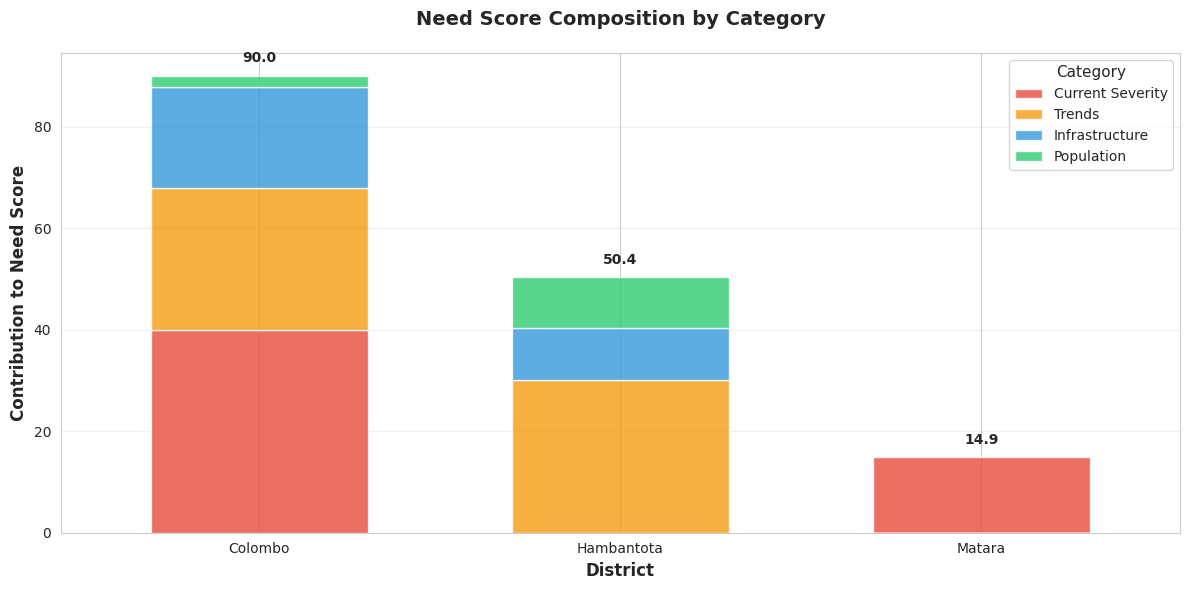

Need score components chart saved to: need_score_components.png


In [15]:
# Visualization 3: Need Score Components
# WHY: Shows what drives each district's score

fig, ax = plt.subplots(figsize=(12, 6))

# Calculate component contributions
component_data = []

for district in scoring_df['District']:
    district_components = {'District': district}

    for feature, info in selected_features.items():
        normalized_col = feature + '_normalized'
        if normalized_col in normalized_df.columns:
            district_idx = normalized_df[normalized_df['District'] == district].index[0]
            normalized_value = normalized_df.loc[district_idx, normalized_col]
            weighted_contribution = normalized_value * info['weight']

            group = info['group'].replace('_', ' ').title()
            if group not in district_components:
                district_components[group] = 0
            district_components[group] += weighted_contribution

    component_data.append(district_components)

components_df = pd.DataFrame(component_data)
components_df = components_df.set_index('District')

# Stacked bar chart
components_df.plot(kind='bar', stacked=True, ax=ax,
                   color=['#e74c3c', '#f39c12', '#3498db', '#2ecc71'],
                   alpha=0.8, width=0.6)

ax.set_xlabel('District', fontsize=12, fontweight='bold')
ax.set_ylabel('Contribution to Need Score', fontsize=12, fontweight='bold')
ax.set_title('Need Score Composition by Category', fontsize=14, fontweight='bold', pad=20)
ax.legend(title='Category', fontsize=10, title_fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.grid(axis='y', alpha=0.3)

# Add total score labels
for i, (district, total_score) in enumerate(zip(scoring_df['District'], scoring_df['need_score'])):
    ax.text(i, total_score + 2, f'{total_score:.1f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_FOLDER + 'need_score_components.png', dpi=300, bbox_inches='tight')
plt.show()

print("Need score components chart saved to: need_score_components.png")

## 11. Sensitivity Analysis

Test how robust allocations are to changes in assumptions.

WHY: Validates model stability - allocations shouldn't swing wildly with minor changes.

In [16]:
# Sensitivity Analysis: Test different weight schemes
# WHY: Shows if rankings are robust to weight assumptions

print("="*120)
print("SENSITIVITY ANALYSIS: WEIGHT VARIATIONS")
print("="*120)
print("\nTesting how allocation changes with different weighting schemes:\n")

# Define alternative weight schemes
WEIGHT_SCENARIOS = {
    'Base Model': {'current_severity': 0.40, 'trends': 0.30, 'infrastructure': 0.20, 'population': 0.10},
    'Current Focus': {'current_severity': 0.60, 'trends': 0.20, 'infrastructure': 0.15, 'population': 0.05},
    'Proactive Focus': {'current_severity': 0.25, 'trends': 0.45, 'infrastructure': 0.25, 'population': 0.05},
    'Equal Weights': {'current_severity': 0.25, 'trends': 0.25, 'infrastructure': 0.25, 'population': 0.25}
}

sensitivity_results = []

for scenario_name, weights in WEIGHT_SCENARIOS.items():
    # Recalculate need scores with new weights
    scenario_scores = normalized_df[['District']].copy()
    scenario_scores['need_score'] = 0

    for feature, info in selected_features.items():
        normalized_col = feature + '_normalized'
        group = info['group']

        # Get new weight for this feature's group
        new_group_weight = weights[group]
        new_feature_weight = new_group_weight / group_counts[group]

        scenario_scores['need_score'] += normalized_df[normalized_col] * new_feature_weight

    # Rank districts
    scenario_scores['rank'] = scenario_scores['need_score'].rank(ascending=False, method='min').astype(int)
    scenario_scores = scenario_scores.sort_values('rank')

    # Calculate allocations
    scenario_scores['allocation_pct'] = ALLOCATION_FLOOR
    total_need = scenario_scores['need_score'].sum()
    for idx, row in scenario_scores.iterrows():
        proportional = (row['need_score'] / total_need) * remaining_allocation
        scenario_scores.at[idx, 'allocation_pct'] += proportional

    # Store results
    for _, row in scenario_scores.iterrows():
        sensitivity_results.append({
            'Scenario': scenario_name,
            'District': row['District'],
            'Rank': row['rank'],
            'Allocation %': row['allocation_pct']
        })

# Create comparison table
sensitivity_df = pd.DataFrame(sensitivity_results)
sensitivity_pivot = sensitivity_df.pivot_table(
    index='District',
    columns='Scenario',
    values='Allocation %',
    aggfunc='first'
).round(1)

# Reorder columns
column_order = ['Base Model', 'Current Focus', 'Proactive Focus', 'Equal Weights']
sensitivity_pivot = sensitivity_pivot[column_order]

print(sensitivity_pivot)

print(f"\n{'='*120}")
print("INTERPRETATION:")
print("="*120)
print("""
Base Model: Our recommended weighting (40/30/20/10)
Current Focus: Emphasizes immediate severity (60% current, 20% trends)
Proactive Focus: Emphasizes prevention (25% current, 45% trends)
Equal Weights: No preference across categories (25% each)

KEY FINDINGS:
""")

# Analyze stability
for district in sensitivity_pivot.index:
    allocations = sensitivity_pivot.loc[district].values
    min_alloc = allocations.min()
    max_alloc = allocations.max()
    range_alloc = max_alloc - min_alloc

    print(f"{district}:")
    print(f"  Range: {min_alloc:.1f}% to {max_alloc:.1f}% (variation: {range_alloc:.1f}%)")

    if range_alloc < 5:
        print(f"  Status: STABLE - allocation robust to weight changes")
    elif range_alloc < 10:
        print(f"  Status: MODERATELY STABLE - some variation but reasonable")
    else:
        print(f"  Status: SENSITIVE - allocation varies significantly with weights")
    print()

print("CONCLUSION:")
avg_range = (sensitivity_pivot.max(axis=1) - sensitivity_pivot.min(axis=1)).mean()
if avg_range < 5:
    print(f"  Model is ROBUST - average variation of {avg_range:.1f}% across scenarios")
elif avg_range < 10:
    print(f"  Model is MODERATELY ROBUST - average variation of {avg_range:.1f}%")
else:
    print(f"  Model is WEIGHT-SENSITIVE - average variation of {avg_range:.1f}%")
    print("  Consider refining weight selection or using equal weights")

print(f"\n{'='*120}")

SENSITIVITY ANALYSIS: WEIGHT VARIATIONS

Testing how allocation changes with different weighting schemes:

Scenario    Base Model  Current Focus  Proactive Focus  Equal Weights
District                                                             
Colombo           54.3           58.7             52.8           49.3
Hambantota        32.6           23.6             37.4           40.4
Matara            13.2           17.7              9.8           10.2

INTERPRETATION:

Base Model: Our recommended weighting (40/30/20/10)
Current Focus: Emphasizes immediate severity (60% current, 20% trends)
Proactive Focus: Emphasizes prevention (25% current, 45% trends)
Equal Weights: No preference across categories (25% each)

KEY FINDINGS:

Colombo:
  Range: 49.3% to 58.7% (variation: 9.4%)
  Status: MODERATELY STABLE - some variation but reasonable

Hambantota:
  Range: 23.6% to 40.4% (variation: 16.8%)
  Status: SENSITIVE - allocation varies significantly with weights

Matara:
  Range: 9.8% to 17.

## 12. Save Outputs

In [17]:
import os

# Save need scores and rankings
output_scores = scoring_df[['rank', 'District', 'need_score', 'tier', 'allocation_pct']].copy()
output_scores.columns = ['Rank', 'District', 'Need_Score', 'Priority_Tier', 'Allocation_Percent']
scores_file = os.path.join(OUTPUT_FOLDER, 'district_need_scores.csv')
output_scores.to_csv(scores_file, index=False)
print(f"Need scores saved to: {scores_file}")

# Save allocation recommendations with example budget
output_allocation = allocation_df[[
    'rank', 'District', 'need_score', 'tier', 'allocation_pct', 'budget_amount'
]].copy()
output_allocation.columns = [
    'Rank', 'District', 'Need_Score', 'Priority_Tier',
    'Allocation_Percent', 'Example_Budget_Amount_Rupees'
]
allocation_file = os.path.join(OUTPUT_FOLDER, 'allocation_recommendations_2025.csv')
output_allocation.to_csv(allocation_file, index=False)
print(f"Allocation recommendations saved to: {allocation_file}")

# Save comparison with baselines
comparison_file = os.path.join(OUTPUT_FOLDER, 'allocation_comparison_baselines.csv')
comparison_df.to_csv(comparison_file, index=False)
print(f"Baseline comparison saved to: {comparison_file}")

# Save sensitivity analysis
sensitivity_file = os.path.join(OUTPUT_FOLDER, 'sensitivity_analysis.csv')
sensitivity_pivot.to_csv(sensitivity_file)
print(f"Sensitivity analysis saved to: {sensitivity_file}")

Need scores saved to: /content/drive/My Drive/output/district_need_scores.csv
Allocation recommendations saved to: /content/drive/My Drive/output/allocation_recommendations_2025.csv
Baseline comparison saved to: /content/drive/My Drive/output/allocation_comparison_baselines.csv
Sensitivity analysis saved to: /content/drive/My Drive/output/sensitivity_analysis.csv


In [18]:
# Create comprehensive allocation report
report_file = os.path.join(OUTPUT_FOLDER, 'allocation_report_2025.txt')

with open(report_file, 'w') as f:
    f.write("="*100 + "\n")
    f.write("2025 CHILD WELFARE RESOURCE ALLOCATION RECOMMENDATIONS\n")
    f.write("Data-Driven Need Assessment and Priority Ranking\n")
    f.write("="*100 + "\n\n")

    f.write("EXECUTIVE SUMMARY\n")
    f.write("-"*100 + "\n")
    f.write(f"Analysis Date: February 2025\n")
    f.write(f"Districts Analyzed: {len(scoring_df)}\n")
    f.write(f"Features Considered: {len(selected_features)}\n")
    f.write(f"Allocation Philosophy: Equitable with {ALLOCATION_FLOOR}% floor\n\n")

    f.write("METHODOLOGY\n")
    f.write("-"*100 + "\n")
    f.write("Composite need scores calculated using weighted combination of:\n")
    for group_name, group_info in FEATURE_GROUPS.items():
        f.write(f"  - {group_name.replace('_', ' ').title()}: {group_info['weight']*100:.0f}% weight\n")
        f.write(f"    {group_info['rationale']}\n")
    f.write("\n")

    f.write("ALLOCATION RECOMMENDATIONS\n")
    f.write("-"*100 + "\n")
    f.write(f"{'Rank':<6} {'District':<15} {'Need Score':<12} {'Tier':<20} {'Allocation %':<15}\n")
    f.write("-"*100 + "\n")
    for _, row in scoring_df.iterrows():
        f.write(f"{row['rank']:<6} {row['District']:<15} {row['need_score']:<12.1f} {row['tier']:<20} {row['allocation_pct']:<15.1f}%\n")
    f.write("\n")

    f.write("DISTRICT-SPECIFIC RECOMMENDATIONS\n")
    f.write("-"*100 + "\n")
    for _, row in scoring_df.iterrows():
        f.write(f"\n{row['District']} (Rank {row['rank']}):\n")
        f.write(f"  Need Score: {row['need_score']:.1f}/100\n")
        f.write(f"  Priority Tier: {row['tier']}\n")
        f.write(f"  Recommended Allocation: {row['allocation_pct']:.1f}%\n")

        if 'Critical' in row['tier']:
            f.write("  Priority Actions:\n")
            f.write("    - Deploy emergency response teams\n")
            f.write("    - Invest in infrastructure (schools, children's homes)\n")
            f.write("    - Launch intensive community awareness programs\n")
            f.write("    - Establish enhanced monitoring systems\n")
        elif 'High' in row['tier']:
            f.write("  Priority Actions:\n")
            f.write("    - Implement preventive programs\n")
            f.write("    - Capacity building for local staff\n")
            f.write("    - Community engagement initiatives\n")
            f.write("    - Regular monitoring and evaluation\n")
        else:
            f.write("  Priority Actions:\n")
            f.write("    - Maintain standard programs\n")
            f.write("    - Routine monitoring\n")
            f.write("    - Infrastructure maintenance\n")

    f.write("\n" + "="*100 + "\n")
    f.write("IMPLEMENTATION NOTES\n")
    f.write("="*100 + "\n")
    f.write("\n")
    f.write("1. BUDGET APPLICATION\n")
    f.write("   The allocation percentages should be applied to your actual available budget.\n")
    f.write("   Example calculations provided assume 50 million rupees for illustration.\n\n")

    f.write("2. FLEXIBILITY\n")
    f.write("   Allocations can be adjusted for:\n")
    f.write("   - Political constraints\n")
    f.write("   - Ongoing program commitments\n")
    f.write("   - Emergency situations\n")
    f.write("   Core principle: Higher-need districts receive proportionally more resources.\n\n")

    f.write("3. MONITORING\n")
    f.write("   Recommended review cycle: Annual\n")
    f.write("   Update analysis with new data each year to track changes in district needs.\n\n")

    f.write("4. TRANSPARENCY\n")
    f.write("   This allocation model is data-driven and transparent.\n")
    f.write("   All calculations are documented and reproducible.\n")
    f.write("   Methodology can be shared with stakeholders and donors.\n\n")

    f.write("="*100 + "\n")
    f.write("END OF REPORT\n")
    f.write("="*100 + "\n")

print(f"Comprehensive report saved to: {report_file}")

print("\n" + "="*100)
print("PHASE 4 COMPLETE")
print("="*100)
print("\nOutputs created:")
print("  1. district_need_scores.csv")
print("  2. allocation_recommendations_2025.csv")
print("  3. allocation_comparison_baselines.csv")
print("  4. sensitivity_analysis.csv")
print("  5. allocation_comparison.png")
print("  6. allocation_breakdown.png")
print("  7. need_score_components.png")
print("  8. allocation_report_2025.txt")
print("\nAll resource allocation recommendations for 2025 are ready!")
print("="*100)

Comprehensive report saved to: /content/drive/My Drive/output/allocation_report_2025.txt

PHASE 4 COMPLETE

Outputs created:
  1. district_need_scores.csv
  2. allocation_recommendations_2025.csv
  3. allocation_comparison_baselines.csv
  4. sensitivity_analysis.csv
  5. allocation_comparison.png
  6. allocation_breakdown.png
  7. need_score_components.png
  8. allocation_report_2025.txt

All resource allocation recommendations for 2025 are ready!
